In [2]:
import numpy as np
import pandas as pd
import os

# 1. List all files in the input directory to confirm paths
print("Available files:")
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# 2. Load the main dataset
# Note: The NYSE dataset usually has 'prices.csv' which is commonly used for regression tasks
# Adjust the path below if the output from step 1 is different (e.g., /kaggle/input/nyse/prices.csv)
try:
    df = pd.read_csv('/kaggle/input/nyse/prices.csv')
    print("\nDataset loaded successfully!")
    print(f"Shape: {df.shape}")
    display(df.head())
except FileNotFoundError:
    print("\nFile not found. Please check the path printed in Step 1.")

Available files:
/kaggle/input/machine-predictive-maintenance-classification/predictive_maintenance.csv
/kaggle/input/nyse/prices-split-adjusted.csv
/kaggle/input/nyse/fundamentals.csv
/kaggle/input/nyse/prices.csv
/kaggle/input/nyse/securities.csv

Dataset loaded successfully!
Shape: (851264, 7)


,date,symbol,open,close,low,high,volume
0,2016-01-05 00:00:00,WLTW,123.430000,125.839996,122.309998,126.250000,2163600.0
1,2016-01-06 00:00:00,WLTW,125.239998,119.980003,119.940002,125.540001,2386400.0
2,2016-01-07 00:00:00,WLTW,116.379997,114.949997,114.930000,119.739998,2489500.0
3,2016-01-08 00:00:00,WLTW,115.480003,116.620003,113.500000,117.440002,2006300.0
4,2016-01-11 00:00:00,WLTW,117.010002,114.970001,114.089996,117.330002,1408600.0


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 851264 entries, 0 to 851263
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    851264 non-null  object 
 1   symbol  851264 non-null  object 
 2   open    851264 non-null  float64
 3   close   851264 non-null  float64
 4   low     851264 non-null  float64
 5   high    851264 non-null  float64
 6   volume  851264 non-null  float64
dtypes: float64(5), object(2)
memory usage: 45.5+ MB
None

--- Basic Statistics ---
                open          close            low           high  \
count  851264.000000  851264.000000  851264.000000  851264.000000   
mean       70.836986      70.857109      70.118414      71.543476   
std        83.695876      83.689686      82.877294      84.465504   
min         0.850000       0.860000       0.830000       0.880000   
25%        33.840000      33.849998      33.480000      34.189999   
50%        52.770000      52.

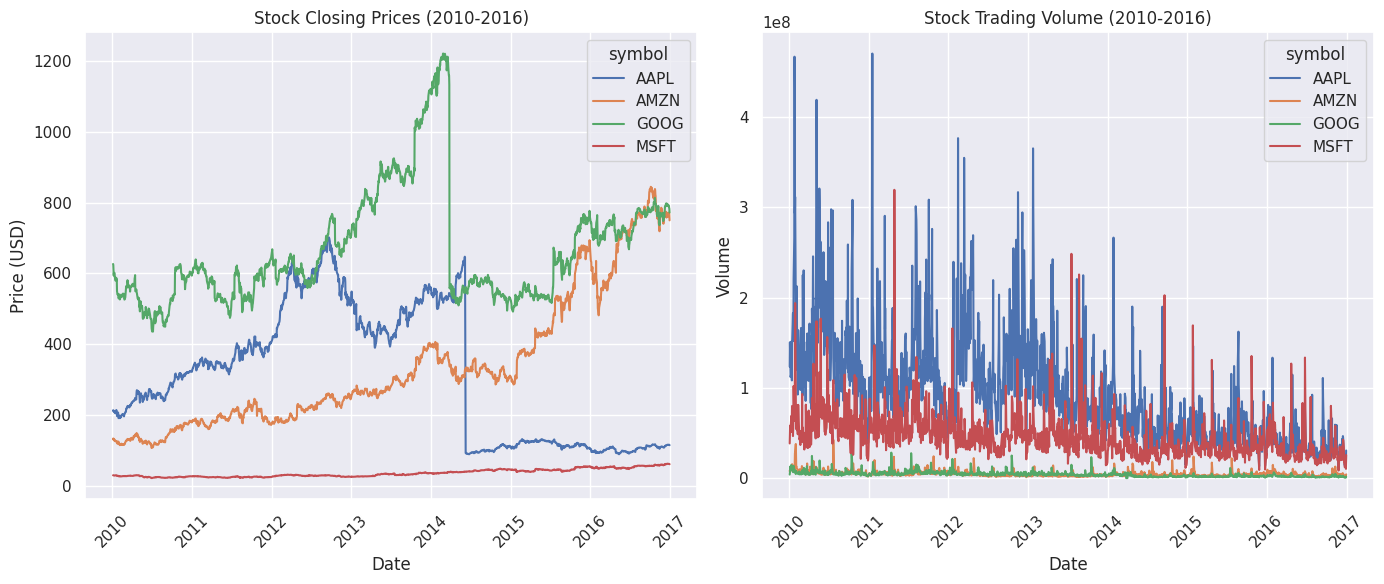

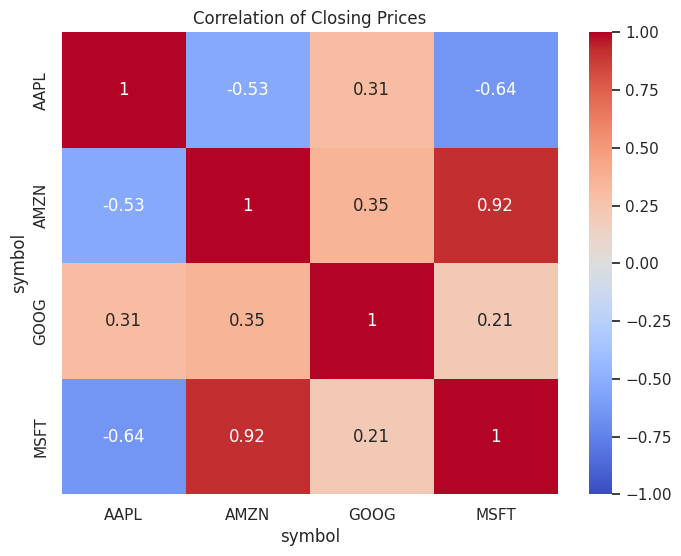

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
# Note: Ensure the dataset is added to your notebook as discussed
df = pd.read_csv('/kaggle/input/nyse/prices.csv')

# 2. General Inspection
print("--- Dataset Info ---")
print(df.info())
print("\n--- Basic Statistics ---")
print(df.describe())

# 3. Data Cleaning & Preparation
# Convert 'date' to datetime object for better plotting
df['date'] = pd.to_datetime(df['date'], format='mixed')
# Check for missing values
print("\n--- Missing Values ---")
print(df.isnull().sum())

# 4. Visualization
# Since there are too many symbols to plot at once, let's filter for a few major tech stocks
target_stocks = ['AAPL', 'GOOG', 'MSFT', 'AMZN']
tech_df = df[df['symbol'].isin(target_stocks)]

# Set plot style
sns.set(style='darkgrid')
plt.figure(figsize=(14, 6))

# Plot 1: Closing Price over Time
plt.subplot(1, 2, 1)
sns.lineplot(data=tech_df, x='date', y='close', hue='symbol')
plt.title('Stock Closing Prices (2010-2016)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.xticks(rotation=45)

# Plot 2: Volume over Time
plt.subplot(1, 2, 2)
sns.lineplot(data=tech_df, x='date', y='volume', hue='symbol')
plt.title('Stock Trading Volume (2010-2016)')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 5. Correlation Matrix (Optional but good for analysis)
# Pivot data to get symbols as columns to check correlation between stocks
pivot_df = tech_df.pivot(index='date', columns='symbol', values='close')
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_df.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation of Closing Prices')
plt.show()

In [4]:
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# 1. Select Data
# We filter for just one stock (AAPL) to perform single-variable regression
stock_data = df[df['symbol'] == 'AAPL']['close'].values.reshape(-1, 1)

# 2. Normalize Data (Scale between 0 and 1)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(stock_data)

# 3. Create Sliding Window Sequences
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

SEQ_LENGTH = 20  # Use past 20 days to predict the next day
X, y = create_sequences(scaled_data, SEQ_LENGTH)

# 4. Convert to PyTorch Tensors
X = torch.from_numpy(X).float()
y = torch.from_numpy(y).float()

# 5. Split Train/Test (80% Train, 20% Test)
# We don't shuffle because order matters in time-series
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: torch.Size([1393, 20, 1])
Test shape: torch.Size([349, 20, 1])


In [5]:
class StockPredictor(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(StockPredictor, self).__init__()
        # Layer 1
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu1 = nn.ReLU()
        # Layer 2
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.relu2 = nn.ReLU()
        # Output Layer (1 unit for regression price)
        self.fc3 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # Flatten the sequence for the MLP (batch_size, seq_len * features) -> (batch_size, input_dim)
        x = x.view(x.shape[0], -1) 
        out = self.fc1(x)
        out = self.relu1(out)
        out = self.fc2(out)
        out = self.relu2(out)
        out = self.fc3(out)
        return out

# Define Model Parameters
INPUT_DIM = SEQ_LENGTH * 1  # 20 days * 1 feature (Close price)
HIDDEN_DIM = 64
OUTPUT_DIM = 1

model = StockPredictor(INPUT_DIM, HIDDEN_DIM, OUTPUT_DIM)
print(model)

StockPredictor(
  (fc1): Linear(in_features=20, out_features=64, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=64, out_features=1, bias=True)
)


In [6]:
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.model_selection import GridSearchCV
import torch.optim as optim

# 1. Define a Wrapper Class to make PyTorch compatible with Sklearn
class PyTorchRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, input_dim=20, hidden_dim=64, output_dim=1, lr=0.01, epochs=50):
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim
        self.lr = lr
        self.epochs = epochs
        self.model = None

    def fit(self, X, y):
        # Initialize model
        self.model = StockPredictor(self.input_dim, self.hidden_dim, self.output_dim)
        criterion = nn.MSELoss()
        optimizer = optim.Adam(self.model.parameters(), lr=self.lr)

        # Training loop
        self.model.train()
        for epoch in range(self.epochs):
            optimizer.zero_grad()
            outputs = self.model(X)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
        return self

    def predict(self, X):
        self.model.eval()
        with torch.no_grad():
            predictions = self.model(X)
        return predictions.numpy()

# 2. Define the Hyperparameter Grid
# We will test different learning rates and hidden layer sizes
param_grid = {
    'lr': [0.001, 0.01],
    'hidden_dim': [32, 64],
    'epochs': [50, 100]  # Kept low for speed; increase for better results
}

# 3. Run GridSearchCV
print("Starting Grid Search...")
# Note: input_dim must match your SEQ_LENGTH from the previous step (20)
estimator = PyTorchRegressor(input_dim=20, output_dim=1)

grid_search = GridSearchCV(
    estimator=estimator,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=3,  # 3-fold cross-validation
    verbose=1
)

# We use the training data from the previous step
# Note: GridSearchCV expects numpy arrays, not Tensors, usually, but our wrapper handles tensors if passed directly.
# However, to be safe with sklearn internals, let's pass the tensors we already created.
grid_search.fit(X_train, y_train)

# 4. Display Best Results
print(f"\nBest Parameters: {grid_search.best_params_}")
best_model = grid_search.best_estimator_

Starting Grid Search...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best Parameters: {'epochs': 100, 'hidden_dim': 32, 'lr': 0.01}


Retraining with Best Params: LR=0.01, Hidden=32, Epochs=100
Epoch [10/100], Train Loss: 0.0082, Test Loss: 0.0001
Epoch [20/100], Train Loss: 0.0047, Test Loss: 0.0004
Epoch [30/100], Train Loss: 0.0026, Test Loss: 0.0001
Epoch [40/100], Train Loss: 0.0021, Test Loss: 0.0000
Epoch [50/100], Train Loss: 0.0019, Test Loss: 0.0001
Epoch [60/100], Train Loss: 0.0016, Test Loss: 0.0001
Epoch [70/100], Train Loss: 0.0014, Test Loss: 0.0000
Epoch [80/100], Train Loss: 0.0013, Test Loss: 0.0000
Epoch [90/100], Train Loss: 0.0012, Test Loss: 0.0000
Epoch [100/100], Train Loss: 0.0011, Test Loss: 0.0000


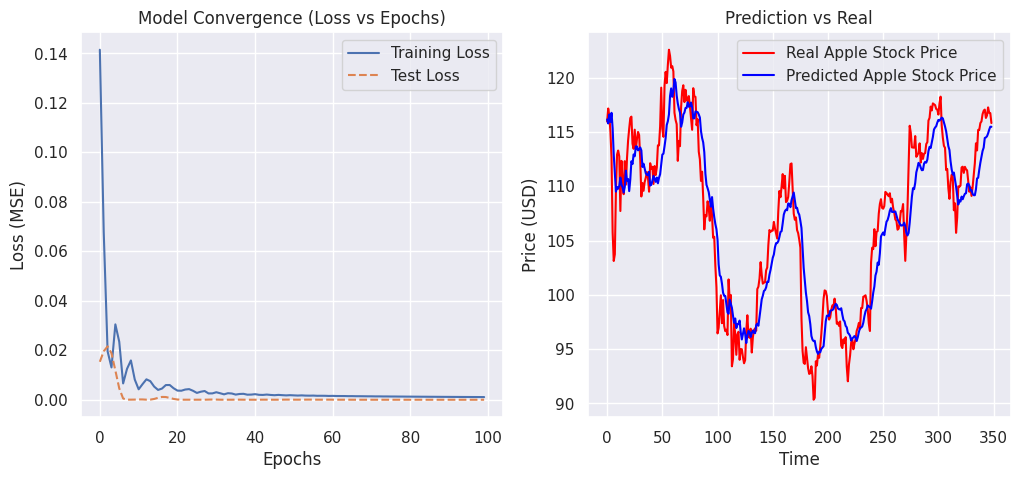

Model R² Score: 0.8567


In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# 1. Retrieve Best Hyperparameters
# If you skipped the long GridSearch, we use these defaults:
best_lr = grid_search.best_params_['lr'] if 'grid_search' in locals() else 0.01
best_hidden = grid_search.best_params_['hidden_dim'] if 'grid_search' in locals() else 64
best_epochs = grid_search.best_params_['epochs'] if 'grid_search' in locals() else 100

print(f"Retraining with Best Params: LR={best_lr}, Hidden={best_hidden}, Epochs={best_epochs}")

# 2. Re-initialize Model
model = StockPredictor(input_dim=20, hidden_dim=best_hidden, output_dim=1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=best_lr)

# 3. Train and Store History
train_losses = []
test_losses = []

for epoch in range(best_epochs):
    # Train
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    # Evaluate (Test)
    model.eval()
    with torch.no_grad():
        test_out = model(X_test)
        test_loss = criterion(test_out, y_test)
        test_losses.append(test_loss.item())

    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{best_epochs}], Train Loss: {loss.item():.4f}, Test Loss: {test_loss.item():.4f}')

# 4. Plot Loss vs Epochs (The "Learning Curve")
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(test_losses, label='Test Loss', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Model Convergence (Loss vs Epochs)')
plt.legend()

# 5. Plot Prediction vs Actual (Visual "Accuracy")
plt.subplot(1, 2, 2)
model.eval()
with torch.no_grad():
    predicted_stock_price = model(X_test).numpy()
    real_stock_price = y_test.numpy()

# Inverse transform to get actual Dollar values back (not 0-1)
predicted_stock_price = scaler.inverse_transform(predicted_stock_price)
real_stock_price = scaler.inverse_transform(real_stock_price)

plt.plot(real_stock_price, color='red', label='Real Apple Stock Price')
plt.plot(predicted_stock_price, color='blue', label='Predicted Apple Stock Price')
plt.title('Prediction vs Real')
plt.xlabel('Time')
plt.ylabel('Price (USD)')
plt.legend()

plt.show()

# Calculate R2 Score (Metric for Regression Accuracy)
r2 = r2_score(real_stock_price, predicted_stock_price)
print(f"Model R² Score: {r2:.4f}")


--- Training Regularized Model ---


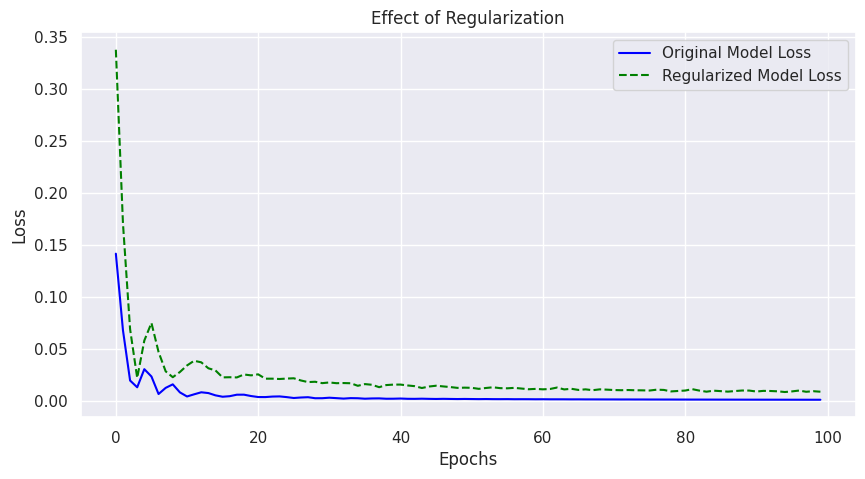

In [8]:
# 1. Define Regularized Model (with Dropout)
class StockPredictorRegularized(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout_prob=0.2):
        super(StockPredictorRegularized, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(p=dropout_prob)  # Regularization 1: Dropout

        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(p=dropout_prob)  # Regularization 1: Dropout

        self.fc3 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = x.view(x.shape[0], -1)
        out = self.dropout1(self.relu1(self.fc1(x)))
        out = self.dropout2(self.relu2(self.fc2(out)))
        out = self.fc3(out)
        return out

# 2. Initialize Regularized Model
reg_model = StockPredictorRegularized(input_dim=20, hidden_dim=best_hidden, output_dim=1)

# Regularization 2: Weight Decay (L2 Regularization) inside Adam
reg_optimizer = torch.optim.Adam(reg_model.parameters(), lr=best_lr, weight_decay=1e-5)
reg_criterion = nn.MSELoss()

# 3. Train Regularized Model
print("\n--- Training Regularized Model ---")
reg_losses = []
for epoch in range(best_epochs):
    reg_model.train()
    reg_optimizer.zero_grad()
    outputs = reg_model(X_train)
    loss = reg_criterion(outputs, y_train)
    loss.backward()
    reg_optimizer.step()
    reg_losses.append(loss.item())

# 4. Compare Loss Curves
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Original Model Loss', color='blue')
plt.plot(reg_losses, label='Regularized Model Loss', color='green', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Effect of Regularization')
plt.legend()
plt.show()

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
# Note: The file is usually named 'predictive_maintenance.csv' or 'ai4i2020.csv' depending on the version.
# We check the directory first to be safe.
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Adjust path below based on the print output above
try:
    # Most likely path:
    df_class = pd.read_csv('/kaggle/input/machine-predictive-maintenance-classification/predictive_maintenance.csv')
    print("\nDataset loaded successfully!")
    display(df_class.head())
except:
    print("Please update the path based on the file listing above.")

/kaggle/input/machine-predictive-maintenance-classification/predictive_maintenance.csv
/kaggle/input/nyse/prices-split-adjusted.csv
/kaggle/input/nyse/fundamentals.csv
/kaggle/input/nyse/prices.csv
/kaggle/input/nyse/securities.csv

Dataset loaded successfully!


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


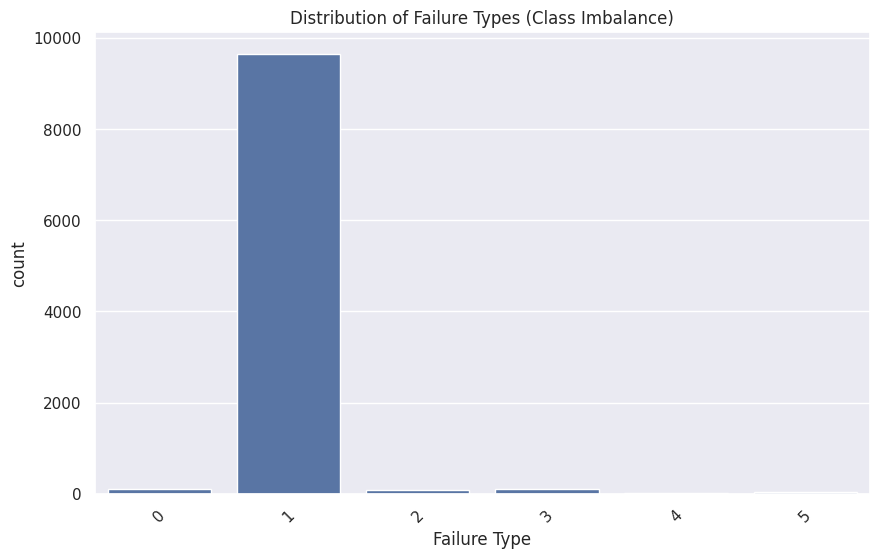

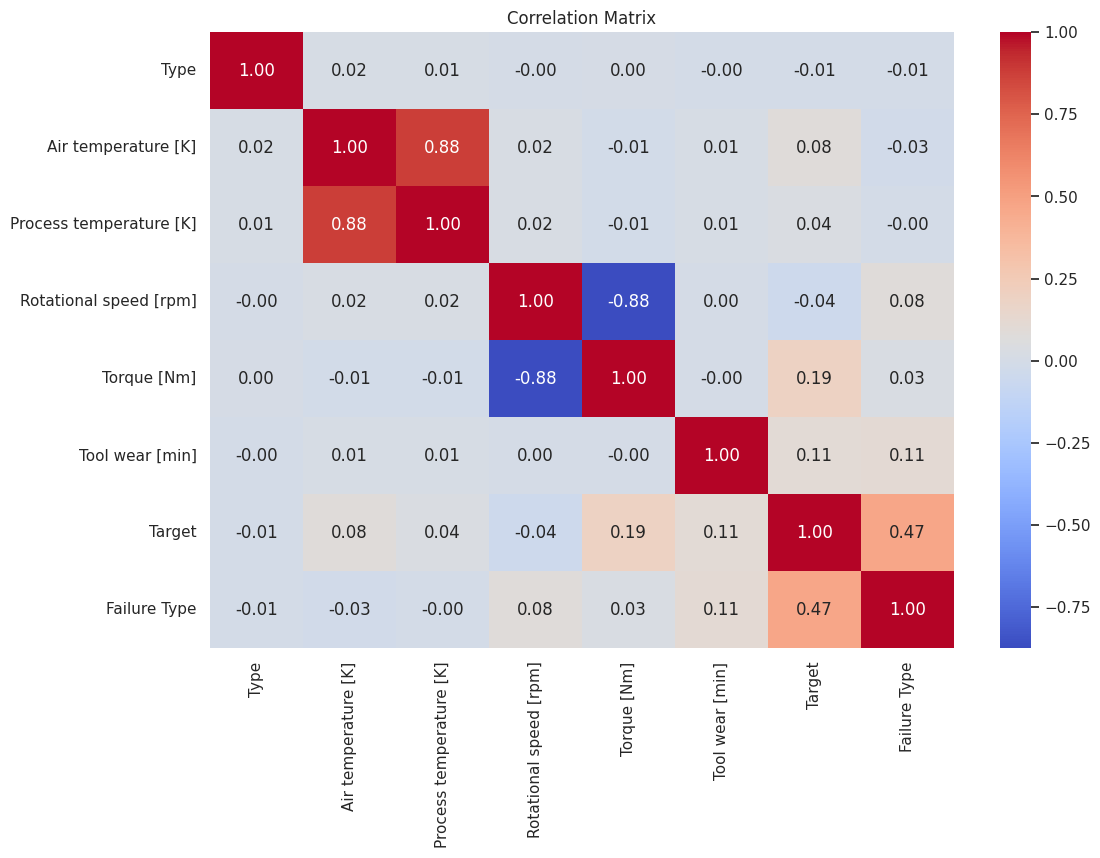

Class mapping: {'Heat Dissipation Failure': np.int64(0), 'No Failure': np.int64(1), 'Overstrain Failure': np.int64(2), 'Power Failure': np.int64(3), 'Random Failures': np.int64(4), 'Tool Wear Failure': np.int64(5)}
Shape of X: (10000, 6)


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

df = pd.read_csv('/kaggle/input/machine-predictive-maintenance-classification/predictive_maintenance.csv')

df = df.drop(['UDI', 'Product ID'], axis=1)

le_type = LabelEncoder()
df['Type'] = le_type.fit_transform(df['Type'])

le_target = LabelEncoder()
df['Failure Type'] = le_target.fit_transform(df['Failure Type'])

X = df.drop(['Target', 'Failure Type'], axis=1)
y = df['Failure Type']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

plt.figure(figsize=(10, 6))
sns.countplot(x='Failure Type', data=df)
plt.title('Distribution of Failure Types (Class Imbalance)')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

print("Class mapping:", dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))
print("Shape of X:", X_scaled.shape)

In [11]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import torch

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("Original Train shape:", X_train.shape)
print("Original Label distribution:\n", y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\nResampled Train shape:", X_train_res.shape)
print("Resampled Label distribution:\n", y_train_res.value_counts())

X_train_tensor = torch.FloatTensor(X_train_res.values)
y_train_tensor = torch.LongTensor(y_train_res.values)

X_test_tensor = torch.FloatTensor(X_test.values)
y_test_tensor = torch.LongTensor(y_test.values)

Original Train shape: (8000, 6)
Original Label distribution:
 Failure Type
1    7722
0      90
3      76
2      62
5      36
4      14
Name: count, dtype: int64

Resampled Train shape: (46332, 6)
Resampled Label distribution:
 Failure Type
1    7722
5    7722
4    7722
3    7722
0    7722
2    7722
Name: count, dtype: int64


In [12]:
import torch.nn as nn
import torch.optim as optim

class MaintenanceClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(MaintenanceClassifier, self).__init__()
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.relu1 = nn.ReLU()
        self.layer2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.relu2 = nn.ReLU()
        self.layer3 = nn.Linear(hidden_dim // 2, output_dim)

    def forward(self, x):
        x = self.relu1(self.layer1(x))
        x = self.relu2(self.layer2(x))
        x = self.layer3(x)
        return x

input_dim = X_train_res.shape[1]
output_dim = len(np.unique(y))
hidden_dim = 64

model_class = MaintenanceClassifier(input_dim, hidden_dim, output_dim)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_class.parameters(), lr=0.001)

epochs = 50
train_losses = []
test_losses = []
train_acc = []
test_acc = []

for epoch in range(epochs):
    model_class.train()
    optimizer.zero_grad()
    outputs = model_class(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())
    _, preds_train = torch.max(outputs, 1)
    train_acc.append((preds_train == y_train_tensor).float().mean().item())

    model_class.eval()
    with torch.no_grad():
        outputs_test = model_class(X_test_tensor)
        loss_test = criterion(outputs_test, y_test_tensor)
        test_losses.append(loss_test.item())
        _, preds_test = torch.max(outputs_test, 1)
        test_acc.append((preds_test == y_test_tensor).float().mean().item())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {loss.item():.4f}, Test Acc: {test_acc[-1]:.4f}")

Epoch 10/50, Train Loss: 1.7016, Test Acc: 0.0195
Epoch 20/50, Train Loss: 1.6071, Test Acc: 0.0485
Epoch 30/50, Train Loss: 1.5005, Test Acc: 0.1050
Epoch 40/50, Train Loss: 1.3787, Test Acc: 0.2020
Epoch 50/50, Train Loss: 1.2464, Test Acc: 0.3065


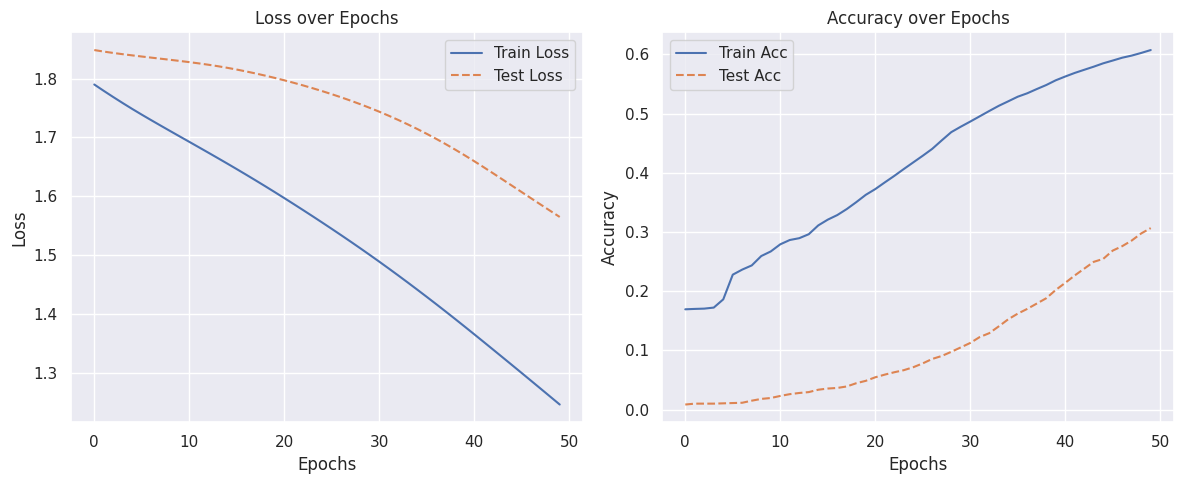

Classification Report:

              precision    recall  f1-score   support

           0       0.06      0.95      0.12        22
           1       1.00      0.29      0.45      1930
           2       0.08      1.00      0.14        16
           3       0.02      0.53      0.04        19
           4       0.00      0.00      0.00         4
           5       0.01      0.56      0.03         9

    accuracy                           0.31      2000
   macro avg       0.20      0.55      0.13      2000
weighted avg       0.96      0.31      0.44      2000



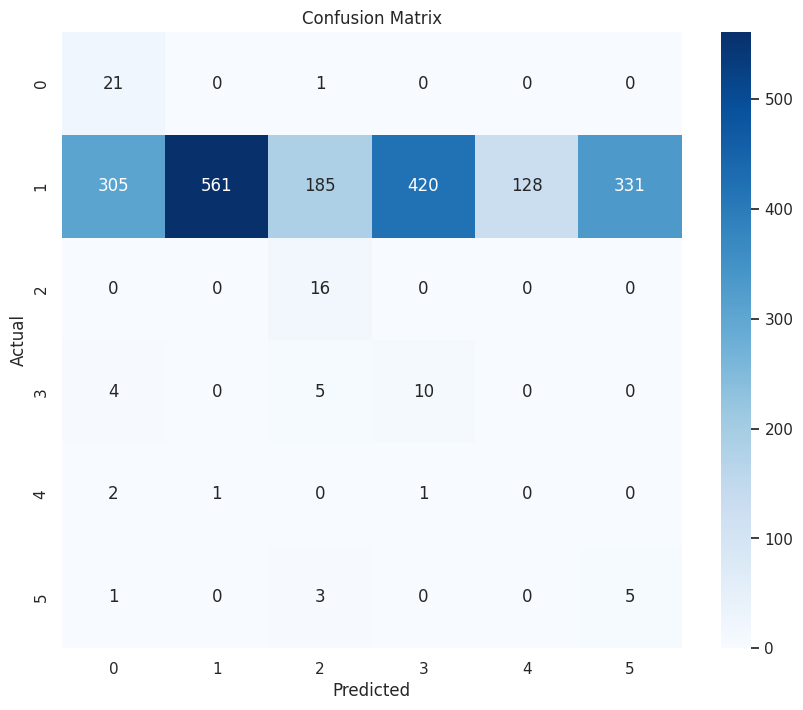

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss', linestyle='--')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc, label='Train Acc')
plt.plot(test_acc, label='Test Acc', linestyle='--')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

model_class.eval()
with torch.no_grad():
    test_outputs = model_class(X_test_tensor)
    _, test_preds = torch.max(test_outputs, 1)

y_true = y_test_tensor.numpy()
y_pred = test_preds.numpy()

print("Classification Report:\n")
print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

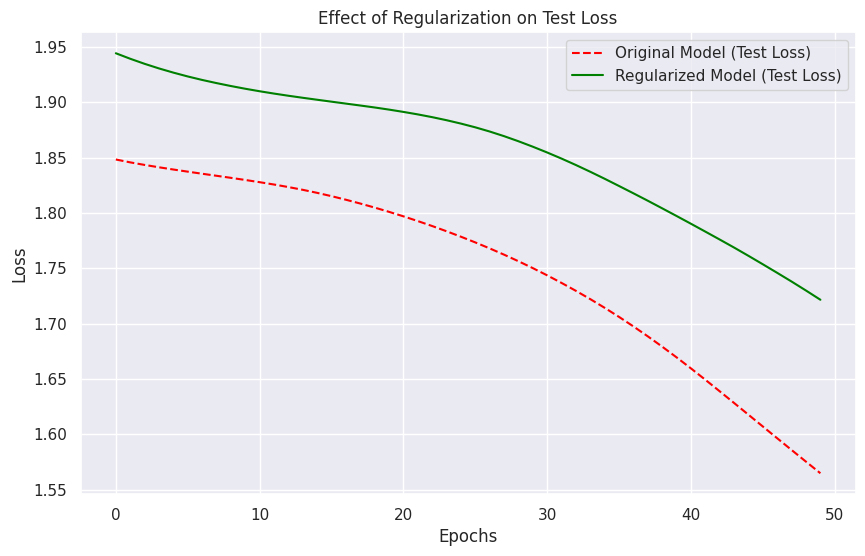

In [14]:
class MaintenanceClassifierRegularized(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout_prob=0.3):
        super(MaintenanceClassifierRegularized, self).__init__()
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(p=dropout_prob)
        self.layer2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(p=dropout_prob)
        self.layer3 = nn.Linear(hidden_dim // 2, output_dim)

    def forward(self, x):
        x = self.dropout1(self.relu1(self.layer1(x)))
        x = self.dropout2(self.relu2(self.layer2(x)))
        x = self.layer3(x)
        return x

reg_model_class = MaintenanceClassifierRegularized(input_dim, hidden_dim, output_dim)
reg_optimizer = optim.Adam(reg_model_class.parameters(), lr=0.001, weight_decay=1e-4)
reg_criterion = nn.CrossEntropyLoss()

reg_test_losses = []

for epoch in range(epochs):
    reg_model_class.train()
    reg_optimizer.zero_grad()
    outputs = reg_model_class(X_train_tensor)
    loss = reg_criterion(outputs, y_train_tensor)
    loss.backward()
    reg_optimizer.step()

    reg_model_class.eval()
    with torch.no_grad():
        outputs_test = reg_model_class(X_test_tensor)
        loss_test = reg_criterion(outputs_test, y_test_tensor)
        reg_test_losses.append(loss_test.item())

plt.figure(figsize=(10, 6))
plt.plot(test_losses, label='Original Model (Test Loss)', color='red', linestyle='--')
plt.plot(reg_test_losses, label='Regularized Model (Test Loss)', color='green')
plt.title('Effect of Regularization on Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()